In [1]:
import pandas as pd
import optuna
import plotly
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Загружаем данные
df = pd.read_csv('https://code.s3.yandex.net/datasets/Hotel_Reservations.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24398 entries, 0 to 24397
Data columns (total 24 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            24398 non-null  str    
 1   no_of_adults                          24398 non-null  int64  
 2   no_of_children                        24398 non-null  int64  
 3   no_of_weekend_nights                  23169 non-null  float64
 4   no_of_week_nights                     23175 non-null  float64
 5   type_of_meal_plan                     24398 non-null  str    
 6   required_car_parking_space            23182 non-null  float64
 7   room_type_reserved                    24398 non-null  str    
 8   lead_time                             24398 non-null  int64  
 9   arrival_year                          24398 non-null  int64  
 10  arrival_month                         24398 non-null  int64  
 11  arrival_date              

In [3]:
# Группы признаков для модели
binary_features = ['is_vip_guest']
categorical_non_binary = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
numerical_with_nan = ['no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space']

In [4]:
# Разделение данных
X = df.drop(["Booking_ID", "avg_price_per_room", "booking_status"], axis=1)
y = df["avg_price_per_room"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Создаём ColumnTransformer с обработкой разных типов признаков
transformers_list = []

# 1. Бинарные признаки - OneHotEncoder с drop="first": убираем первый столбец каждой категории, чтобы избежать дамми-ловушки
if binary_features:
    transformers_list.append(("binary", OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first"), binary_features))

# 2. Категориальные небинарные - OneHotEncoder
if categorical_non_binary:
    transformers_list.append(
        ("categorical", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), categorical_non_binary)
    )

# 3. Числовые с NaN - SimpleImputer с -999999
if numerical_with_nan:
    transformers_list.append(
        ("imputer", SimpleImputer(fill_value=-999999), numerical_with_nan)
    )

preproccesor = ColumnTransformer(transformers=
    transformers_list,
    remainder='passthrough'
)

# Базовая модель

In [6]:
# Определяем пайплайн с базовой моделью
model_base = DecisionTreeRegressor(
    random_state=42,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10
)

pipeline = Pipeline(steps=[
    ('preprocessor', preproccesor),
    ('model', model_base)
])

In [7]:
# Настраиваем кросс-валидацию
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Набор метрик для оценки
scoring = {
    'MAE': make_scorer(mean_absolute_error),
    'MSE': make_scorer(mean_squared_error),
    'R2': make_scorer(r2_score)
}

In [8]:
# Оцениваем качество модели на кросс-валидации
cv_results_base = cross_validate(
    pipeline,
    X_train,
    y_train,
    scoring=scoring,
    cv=cv
)

In [9]:
# Выводим результаты
for metric, scores in cv_results_base.items():
    if 'test' in metric:
        print(f'Среднее значение {metric.replace('test_', '')}: {scores.mean():.3f}')

for metric, scores in cv_results_base.items():
    if "test" in metric:
        print(f"Стандартное отклонение {metric.replace('test_', '')}: {scores.std():.4f}")

Среднее значение MAE: 14.217
Среднее значение MSE: 447.245
Среднее значение R2: 0.629
Стандартное отклонение MAE: 0.2259
Стандартное отклонение MSE: 32.2830
Стандартное отклонение R2: 0.0285


# Подбор гиперпараметров через Optuna

In [10]:
# Настраиваем кросс-валидацию
cv_opuna = KFold(n_splits=5, shuffle=True, random_state=42)

In [11]:
# Задаем функцию-цель для оптимизации optuna
def objective(trial):
    # Пространство поиска гиперпараметров
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20)
    }
    # Задаем модель с гиперпараметрами из пространства поиска
    model = DecisionTreeRegressor(**params, random_state=42)
    # Указываем пайплайн
    pipeline = Pipeline(steps=[
        ('preprocessor', preproccesor),
        ('model', model)
    ])
    # Определяем метрику
    scorer = make_scorer(mean_absolute_error)
    # Задаем кросс-валидацию
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        scoring=scorer,
        cv=cv_opuna
    )

    return scores.mean()

In [12]:
# Запуск исследования
# Фиксируем сид через самплер
sampler = optuna.samplers.TPESampler(seed=42)

study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=15, show_progress_bar=True)

[I 2026-06-22 14:57:13,664] A new study created in memory with name: no-name-f6eb8841-4e1c-4228-bf32-9ca336a49bc9


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-06-22 14:57:14,141] Trial 0 finished with value: 16.994976759488274 and parameters: {'max_depth': 7, 'min_samples_split': 48, 'min_samples_leaf': 15}. Best is trial 0 with value: 16.994976759488274.
[I 2026-06-22 14:57:14,610] Trial 1 finished with value: 14.129025407703548 and parameters: {'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 1 with value: 14.129025407703548.
[I 2026-06-22 14:57:14,930] Trial 2 finished with value: 20.498730288435368 and parameters: {'max_depth': 3, 'min_samples_split': 44, 'min_samples_leaf': 13}. Best is trial 1 with value: 14.129025407703548.
[I 2026-06-22 14:57:15,421] Trial 3 finished with value: 13.47471625155742 and parameters: {'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 20}. Best is trial 3 with value: 13.47471625155742.
[I 2026-06-22 14:57:16,000] Trial 4 finished with value: 12.30087399829111 and parameters: {'max_depth': 13, 'min_samples_split': 12, 'min_samples_leaf': 4}. Best is trial 4 w

In [13]:
# Лучшие гиперпараметры и качество
best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)
best_value = study.best_value
print("Лучшее среднее значение MAE на кросс-валидации:", best_value)

Лучшие гиперпараметры: {'max_depth': 13, 'min_samples_split': 12, 'min_samples_leaf': 4}
Лучшее среднее значение MAE на кросс-валидации: 12.30087399829111


In [25]:
# Определяем пайплайн с оптимизированной моделью
model_best = DecisionTreeRegressor(**best_params, random_state=42)

# Формируем пайплайн
pipeline_best = Pipeline(steps=[
    ('preproccesor', preproccesor),
    ('model', model_best)
])

In [26]:
# Оцениваем качество модели на кросс-валидации
cv_results_best = cross_validate(
    pipeline_best,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

# Выводим результаты
for metric, scores in cv_results_best.items():
    if "test" in metric:
        print(f"Среднее значение {metric.replace('test_', '')}: {scores.mean():.3f}")

for metric, scores in cv_results_best.items():
    if "test" in metric:
        print(f"Стандартное отклонение {metric.replace('test_', '')}: {scores.std():.4f}")

Среднее значение MAE: 12.301
Среднее значение MSE: 387.446
Среднее значение R2: 0.679
Стандартное отклонение MAE: 0.2307
Стандартное отклонение MSE: 35.0096
Стандартное отклонение R2: 0.0286


In [ ]:
# Обучите финальную модель
final_pipeline = Pipeline([
    ('preprocessor', preproccesor),
    ('model', model_best)
])

final_pipeline.fit(X_train, y_train)

# Получите предсказания
y_pred = final_pipeline.predict(X_test)

In [28]:
# Рассчитайте метрики
print("MAE на тестовой выборке:", round(mean_absolute_error(y_test,y_pred),3))
print("MSE на тестовой выборке:", round(mean_squared_error(y_test,y_pred),3))
print("R2 на тестовой выборке:", round(r2_score(y_test,y_pred),3))

MAE на тестовой выборке: 12.049
MSE на тестовой выборке: 360.953
R2 на тестовой выборке: 0.688


In [36]:
# Расчёт feature importance
# Достаём отдельные этапы пайплайна final_pipeline и сохраняем их в отдельные переменные
preproccesoring = final_pipeline.named_steps['preprocessor']
final_model = final_pipeline.named_steps['model']

# Создаём таблицу с feature importance
feature_importance = pd.DataFrame({
    'feature': preproccesoring.get_feature_names_out(),
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

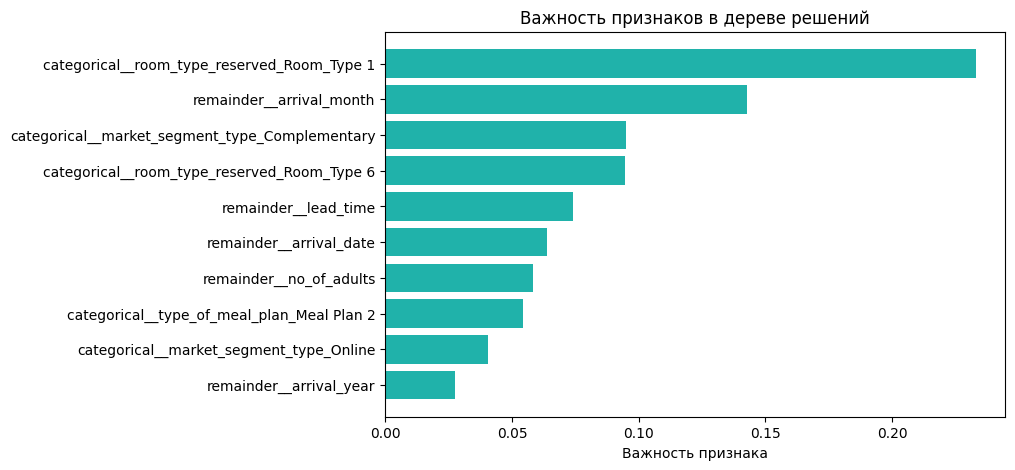

In [37]:
# Визуализация важности для топ-10 признаков
top_10_feature_names = feature_importance['feature'].values[:10]
top_10_feature_importance = feature_importance['importance'].values[:10]

plt.figure(figsize=(8, 5))
plt.barh(top_10_feature_names, top_10_feature_importance, color='lightseagreen')
plt.xlabel('Важность признака')
plt.title('Важность признаков в дереве решений')
plt.gca().invert_yaxis()
plt.show()